In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

d:\DP Larning\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9157 - loss: 0.2749 - val_accuracy: 0.9748 - val_loss: 0.0835
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9744 - loss: 0.0842 - val_accuracy: 0.9762 - val_loss: 0.0779
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9815 - loss: 0.0598 - val_accuracy: 0.9827 - val_loss: 0.0601
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9851 - loss: 0.0475 - val_accuracy: 0.9833 - val_loss: 0.0578
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9872 - loss: 0.0396 - val_accuracy: 0.9872 - val_loss: 0.0415
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9872 - loss: 0.0415

Test accuracy :0.9872


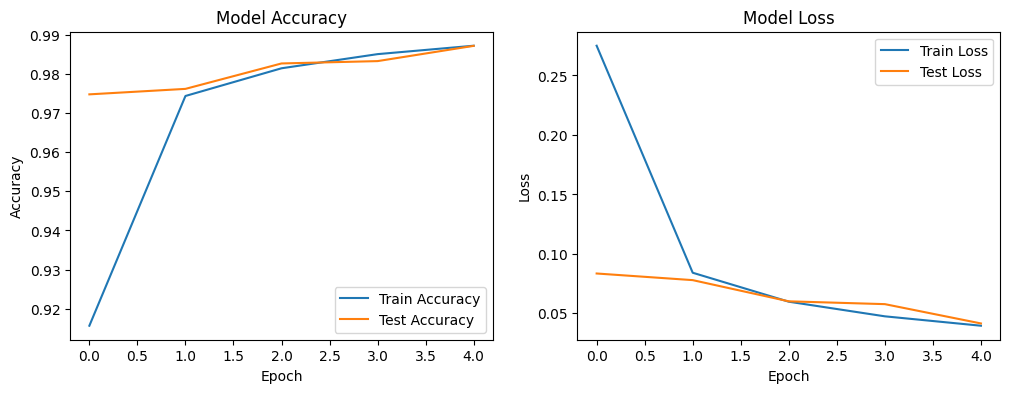

In [2]:

# Load and preprocess the MNIST dataset
(x_train,y_train), (x_test,y_test) = mnist.load_data()

# Reshape the data to add a channel dimension 
x_train = x_train.reshape((x_train.shape[0],28,28,1)).astype('float32')/255
x_test = x_test.reshape((x_test.shape[0],28,28,1)).astype('float32')/255

# covert labels to categorical one-hot encoding 
y_train = tf.keras.utils.to_categorical(y_train,10)
y_test = tf.keras.utils.to_categorical(y_test,10)

# Buling the CNN model
model = models.Sequential()
model.add(layers.Conv2D(32,(3,3),activation="relu",input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation="relu"))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation="relu"))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(64,activation="relu"))
model.add(layers.Dense(10,activation="softmax"))


# Compile the model
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

# Train the model 

history = model.fit(x_train,y_train,epochs=5,batch_size=64,validation_data=(x_test,y_test))

#Evaluate the model 
test_loss , test_acc = model.evaluate(x_test,y_test)
print(f'\nTest accuracy :{test_acc:.4f}')

# Plot training & validation accuracy and loss values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()

In [3]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181,664 (709.63 KB)

 Trainable params: 60,554 (236.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 121,110 (473.09 KB)

# **IMAGE DATA LOADING AND RESHAPING**

In [ ]:
# What happen when you have raw images in my folder , and how you read them  
# so how i get data 
# i mean how will you import  

# so use the fuction for read image or data from particular folder   by cv2 

In [6]:
import cv2

In [9]:
img = cv2.imread(r"D:\DP Larning\1.JPG")

In [10]:
img.shape

(1127, 800, 3)

In [11]:
reshape = img.reshape(1,img.shape[0],img.shape[1],img.shape[2])

In [12]:
reshape .shape

(1, 1127, 800, 3)

In [ ]:
reshape[0][0][0][2]  # image height width color_channel 

np.uint8(249)

In [24]:
# now access the lot of images  using libraery  ---> glob 

In [35]:
from glob import glob
import numpy as np
import cv2

files = glob(r"D:\DP Larning\PetImages\Cat\*.jpg") + \
        glob(r"D:\DP Larning\PetImages\Dog\*.jpg")

print(len(files))

24998


In [37]:
images = []

for i in files:
    img = cv2.imread(i)
    
    if img is not None:   # corrupted image skip
        resized_img = cv2.resize(img,(28,28))
        images.append(resized_img)

In [38]:
images =np.array(images)

In [39]:
images

array([[[[ 94, 171, 210],
         [105, 184, 225],
         [115, 194, 235],
         ...,
         [158, 228, 251],
         [148, 221, 251],
         [128, 208, 245]],

        [[ 97, 171, 213],
         [102, 178, 220],
         [110, 188, 231],
         ...,
         [167, 233, 252],
         [146, 219, 249],
         [138, 216, 245]],

        [[ 96, 170, 212],
         [101, 177, 219],
         [101, 176, 220],
         ...,
         [168, 233, 254],
         [148, 221, 251],
         [148, 222, 248]],

        ...,

        [[ 66, 137, 174],
         [ 69, 140, 177],
         [ 48, 114, 144],
         ...,
         [  3,   7,   8],
         [  4,  14,  14],
         [  1,  10,  13]],

        [[ 65, 132, 168],
         [ 67, 138, 175],
         [ 51, 121, 151],
         ...,
         [  1,   6,   6],
         [  1,   6,   6],
         [  1,   6,   4]],

        [[ 59, 127, 159],
         [ 62, 134, 168],
         [ 55, 128, 158],
         ...,
         [  2,   5,   5],
        

In [ ]:
# ==============================
# CNN BASIC QUESTIONS & ANSWERS
# ==============================

# Q1) Image ko matrix me convert kyu karte hain?
# Answer:
# Computer image ko photo ki tarah nahi samajhta.
# Computer image ko numbers (pixel values) ki matrix ke form me samajhta hai.
# Isliye image ko matrix me convert kiya jata hai taaki CNN model usko process kar sake.


# Q2) Ek image ka matrix size kya hota hai?
# Answer:
# RGB image ka matrix size hota hai:
# (Height , Width , Channels)
# Example:
# (28 , 28 , 3)
# 28 = Height
# 28 = Width
# 3 = RGB channels


# Q3) images.shape = (24997,28,28,3) ka kya meaning hai?
# Answer:
# 24997 = Total images
# 28 = Image height
# 28 = Image width
# 3 = RGB channels
# Matlab dataset me 24997 images hain aur har image ka size 28×28×3 hai.


# Q4) Har image ke liye matrix banta hai kya?
# Answer:
# Haan.
# Har image ek alag matrix hoti hai.
# Example:
# images[0] → First image matrix
# images[1] → Second image matrix


# Q5) images[0].shape kya batata hai?
# Answer:
# images[0].shape = (28,28,3)
# Matlab first image ka matrix size 28×28×3 hai.


# Q6) Pixel kya hota hai?
# Answer:
# Image chhote chhote pixels se milkar bani hoti hai.
# Har pixel me color value hoti hai.


# Q7) images[0][0][0] kya batata hai?
# Answer:
# Ye first image ka first pixel ka RGB value batata hai.
# Example:
# [94 171 210]
# 94 = Red
# 171 = Green
# 210 = Blue


# Q8) CNN input format kya hota hai?
# Answer:
# CNN input format hota hai:
# (Batch_size , Height , Width , Channels)

# Example:
# (24997 , 28 , 28 , 3)


# Q9) Batch size kya hota hai?
# Answer:
# Batch size batata hai ek time me kitni images model me jayengi.
# Example:
# (1,28,28,3) → 1 image
# (32,28,28,3) → 32 images


# Q10) reshape(1,28,28,3) kyu use karte hain?
# Answer:
# reshape image me batch dimension add karta hai.
# CNN model ko input format chahiye:
# (Batch , Height , Width , Channels)
# Isliye reshape use karte hain.


# Q11) img.shape kya batata hai?
# Answer:
# img.shape image ka size batata hai.
# Example:
# (1127,800,3)
# 1127 = Height
# 800 = Width
# 3 = Channels


# Q12) img.shape[0], img.shape[1], img.shape[2] kyu use karte hain?
# Answer:
# Ye image ka height, width aur channels automatically nikalte hain.
# Isse code flexible ban jata hai.


# Q13) cv2.resize(img,(28,28)) kyu use kiya?
# Answer:
# CNN model me sab images ka same size hona zaroori hai.
# Isliye images ko resize karke 28×28 kiya.


# Q14) images = np.array(images) kya karta hai?
# Answer:
# Ye list of images ko NumPy array me convert karta hai.
# CNN model NumPy array input leta hai.


# Q15) Image ka data numbers me kyu hota hai?
# Answer:
# Har pixel ki value 0–255 ke beech hoti hai.
# Example:
# [94 171 210]
# Ye pixel ka RGB color batata hai.


# Q16) CNN image ko kaise dekhta hai?
# Answer:
# CNN image ko numbers ki matrix ke form me dekhta hai.
# Image = Matrix of pixel values.


# Q17) Har image ka matrix size same kyu hona chahiye?
# Answer:
# CNN model ko fixed input size chahiye.
# Agar size different hua to model train nahi hoga.


# Q18) Dataset ka final format kya hota hai?
# Answer:
# (Number_of_images , Height , Width , Channels)

# Example:
# (24997 , 28 , 28 , 3)


# Q19) RGB channels kya hote hain?
# Answer:
# RGB = Red Green Blue
# Har pixel me 3 values hoti hain.
# Isliye channel = 3


# Q20) Computer image ko kaise store karta hai?
# Answer:
# Computer image ko matrix ke form me store karta hai.
# Har pixel ek number hota hai.